# **DATA UNDERSTANDING AND CLEANING**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_excel('/content/online_retail_II.xlsx')

In [3]:
df2 = pd.read_excel('online_retail_II.xlsx',sheet_name='Year 2010-2011')

In [4]:
df = pd.concat([df1,df2],ignore_index=True)

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [7]:
df.shape

(1067371, 8)

In [8]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [9]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,1067371.0,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.0,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445


In [10]:
df.describe(exclude='number').T

,count,unique,top,freq,mean,min,25%,50%,75%,max
Invoice,1067371.0,53628.0,537434.0,1350.0,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN
InvoiceDate,1067371,NaN,NaN,NaN,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [12]:
#DATA CLEANING

In [13]:
#dropping null customer id
df = df[df['Customer ID'].notna()]

In [14]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [15]:
#checking duplicates
df.duplicated().sum()

np.int64(26479)

In [16]:
df[df.duplicated(
    subset=['Invoice', 'InvoiceDate', 'StockCode', 'Quantity'],
    keep=False
)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067136,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
1067150,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
1067153,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
1067160,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


one row = one product inside an invoice

Checking all the cancelled invoices has negative qty and all thenegative qty is canceled

In [17]:
cancel = df[df['Invoice'].astype(str).str.startswith('C', na=False)]
(cancel['Quantity'] < 0).all()

np.True_

In [18]:
negative_qty = df[df['Quantity'] < 0]
negative_qty['Invoice'].astype(str).str.startswith('C', na=False).all()

np.True_

In [19]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [20]:
#Feature engineering

In [21]:
dfex = df.copy()

# **COHORT ANALYSIS**
A cohort is just a group of people who share something in common at the same point in time.
In our case:

"All customers who made their first ever purchase in December 2009"  that's one cohort.

Then we ask:

Of those customers, how many came back in January? February? March?

That's it. We're just tracking did this customer come back or not. Month after month after month.

In [22]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
# which month did this transaction happen

In [23]:
df['CohortMonth']= df.groupby('Customer ID')['InvoiceMonth'].transform('min')
# which month did this customer make their VERY FIRST purchase ever

In [24]:
df['CohortIndex'] =(df['InvoiceMonth'] - df['CohortMonth']).apply(lambda x: x.n)
#how many months after their first purchase is this transaction?

In [25]:
df['CohortIndex']

,CohortIndex
0,0
1,0
2,0
3,0
4,0
...,...
1067366,4
1067367,4
1067368,4
1067369,4


In [26]:
cohort_data = df.pivot_table(
    index = 'CohortMonth',
    columns = 'CohortIndex',
    values = 'Customer ID',
    aggfunc = 'nunique'
)

In [27]:
cohort_data

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,...,289.0,251.0,289.0,270.0,248.0,244.0,301.0,291.0,389.0,188.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,...,58.0,90.0,76.0,71.0,75.0,93.0,74.0,94.0,22.0,NaN
2010-02,376.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,...,75.0,60.0,61.0,54.0,86.0,86.0,61.0,22.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,48.0,...,75.0,77.0,69.0,78.0,89.0,94.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,31.0,32.0,...,46.0,41.0,44.0,53.0,66.0,17.0,NaN,NaN,NaN,NaN
2010-05,254.0,40.0,43.0,44.0,45.0,65.0,54.0,32.0,15.0,21.0,...,32.0,35.0,42.0,39.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,270.0,47.0,51.0,55.0,62.0,77.0,34.0,24.0,22.0,32.0,...,33.0,36.0,55.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,26.0,21.0,27.0,27.0,21.0,...,32.0,44.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.0,33.0,48.0,52.0,28.0,19.0,16.0,20.0,22.0,21.0,...,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
retention = cohort_data.divide(cohort_data[0],axis=0).round(3)

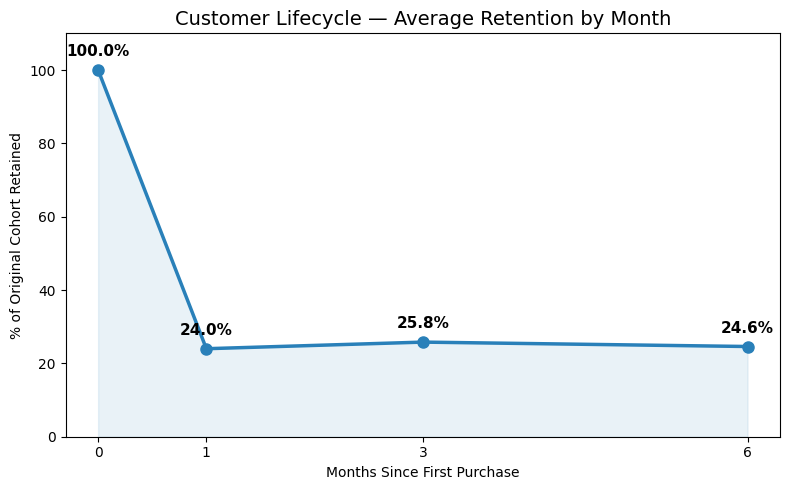

In [29]:
funnel_cols = [0, 1, 3, 6]
funnel_cols = [c for c in funnel_cols if c in cohort_data.columns]

funnel = cohort_data[funnel_cols].mean()
funnel_pct = (funnel / funnel[0] * 100).round(1)

plt.figure(figsize=(8, 5))
plt.plot(funnel_pct.index, funnel_pct.values,
         marker='o', linewidth=2.5, color='#2980b9', markersize=8)

for x, y in zip(funnel_pct.index, funnel_pct.values):
    plt.annotate(f'{y}%', (x, y),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=11, fontweight='bold')

plt.fill_between(funnel_pct.index, funnel_pct.values, alpha=0.1, color='#2980b9')
plt.title('Customer Lifecycle — Average Retention by Month', fontsize=14)
plt.xlabel('Months Since First Purchase')
plt.ylabel('% of Original Cohort Retained')
plt.xticks(funnel_pct.index)
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [30]:
retention

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.353,0.334,0.425,0.380,0.359,0.377,0.342,0.336,0.362,...,0.303,0.263,0.303,0.283,0.260,0.255,0.315,0.305,0.407,0.197
2010-01,1.0,0.206,0.311,0.305,0.264,0.300,0.258,0.230,0.279,0.319,...,0.151,0.235,0.198,0.185,0.196,0.243,0.193,0.245,0.057,NaN
2010-02,1.0,0.237,0.223,0.290,0.245,0.199,0.191,0.285,0.253,0.274,...,0.199,0.160,0.162,0.144,0.229,0.229,0.162,0.059,NaN,NaN
2010-03,1.0,0.190,0.230,0.242,0.233,0.203,0.246,0.302,0.275,0.108,...,0.169,0.174,0.156,0.176,0.201,0.212,0.079,NaN,NaN,NaN
2010-04,1.0,0.194,0.194,0.163,0.184,0.224,0.276,0.262,0.105,0.109,...,0.156,0.139,0.150,0.180,0.224,0.058,NaN,NaN,NaN,NaN
2010-05,1.0,0.157,0.169,0.173,0.177,0.256,0.213,0.126,0.059,0.083,...,0.126,0.138,0.165,0.154,0.047,NaN,NaN,NaN,NaN,NaN
2010-06,1.0,0.174,0.189,0.204,0.230,0.285,0.126,0.089,0.081,0.119,...,0.122,0.133,0.204,0.052,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.156,0.183,0.296,0.290,0.140,0.113,0.145,0.145,0.113,...,0.172,0.237,0.081,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.204,0.296,0.321,0.173,0.117,0.099,0.123,0.136,0.130,...,0.198,0.068,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


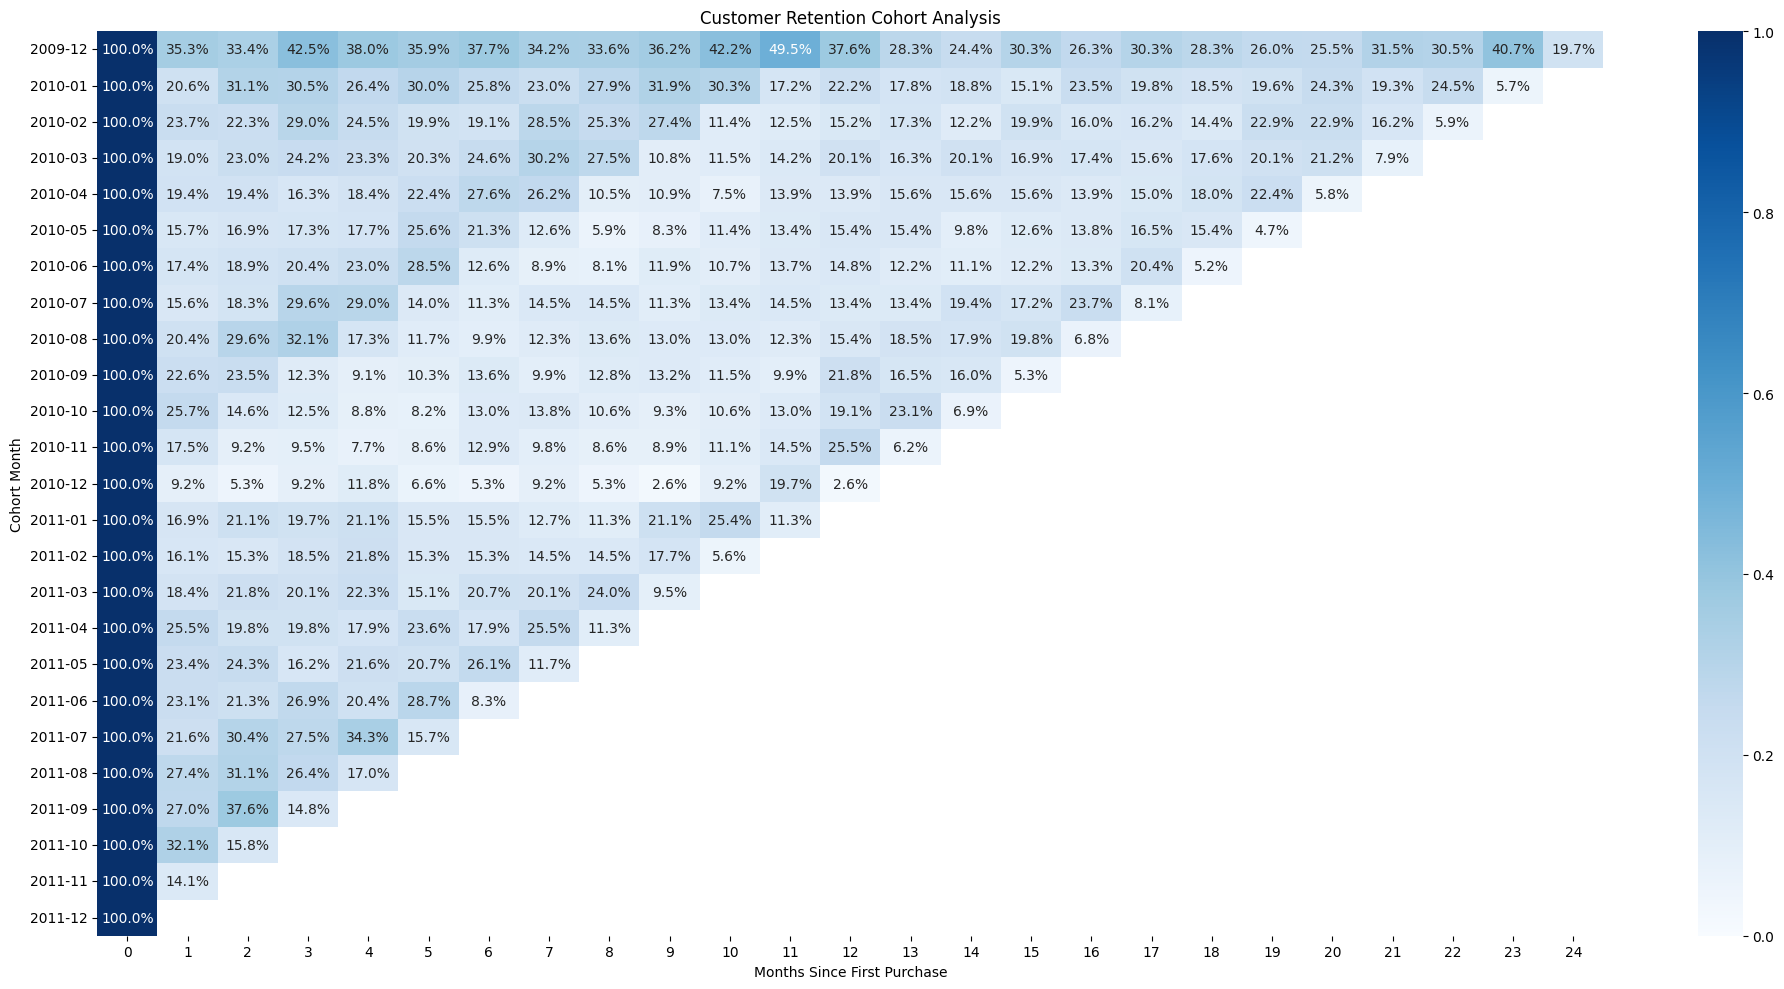

In [33]:
# 1.cohort heatmap
plt.figure(figsize=(20,10))
sns.heatmap(retention, annot=True, fmt='.1%', cmap='Blues', vmin=0, vmax=1)
plt.title('Customer Retention Cohort Analysis')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.tight_layout()
plt.savefig('cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**Cohort Analysis Insights**

**Older cohorts are more loyal:** Customers acquired in 2009 retain ~35%
in month 1, while 2011 cohorts retain as low as 9-14%. Customer quality
has declined over time.

**Month 0→1 is the critical dropoff:** The business loses the majority
of new customers within the first 30 days. Retention efforts should focus
entirely on converting first-time buyers within that window.

**Seasonal buyers exist in early cohorts:** The 2009-12 cohort shows
retention spikes every December. These customers are holiday shoppers
don't waste budget trying to engage them year round, double down on
Q4 campaigns instead.

**2010-12 is an anomaly worth investigating:** Only 9.2% month 1
retention  unusually low. Warrants deeper diagnostic analysis on
cancellation rates and revenue that month.

**2011 cohorts cannot be fairly judged yet:** Shorter rows in the
heatmap reflect limited data, not necessarily worse customers.





# **RMF ANALYSIS**

In [38]:
reference_date = df['InvoiceDate'].max()

In [39]:
df['Revenue']= df['Quantity'] * df['Price']

In [40]:
rfm = df.groupby('Customer ID').agg(
    Recency = ('InvoiceDate','max'), #Recency (R)  How recently the customer purchased
    Frequency = ('Invoice','nunique'), #Frequency (F)  How often the customer purchased
    Monetary = ('Revenue','sum') # Monetary (M)  Total money spent by customer
)


In [41]:
rfm['Recency'] = (reference_date - rfm['Recency']).dt.days

In [42]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,12,77556.46
12347.0,1,8,5633.32
12348.0,74,5,2019.40
12349.0,18,4,4428.69
12350.0,309,1,334.40


In [43]:
rfm['R Score'] = pd.qcut(rfm['Recency'],q=4, labels=[4,3,2,1])
rfm['F Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),q=4,labels = [1,2,3,4])
rfm['M Score'] = pd.qcut(rfm['Monetary'],q=4,labels=[1,2,3,4])

In [44]:
rfm.head()

,Recency,Frequency,Monetary,R Score,F Score,M Score
Customer ID,,,,,,
12346.0,325,12,77556.46,2,4,4
12347.0,1,8,5633.32,4,4,4
12348.0,74,5,2019.40,3,3,3
12349.0,18,4,4428.69,4,3,4
12350.0,309,1,334.40,2,1,1


# **INITIAL RMF APPROACH**

⚠️ INITIAL APPROACH — Simple RFM scoring (summing R+F+M)

Limitation: R=4,F=1,M=1 scores same as R=2,F=2,M=2




In [45]:
# rfm['RFM_Segment'] = (
#     rfm['R Score'].astype(str) +
#     rfm['F Score'].astype(str) +
#     rfm['M Score'].astype(str)
# )

Converts R, F, and M scores into strings and joins them together.

Example: 4 + 3 + 2 becomes '432' which represents the customer segment.

In [ ]:
# rfm['RFM_Score'] = (
#     rfm['R Score'].astype(int) +
#     rfm['F Score'].astype(int) +
#     rfm['M Score'].astype(int)
# )

Converts R, F, and M scores into integers and adds them together.

Example: 4 + 3 + 2 = 9, giving one overall customer score.

In [ ]:
# def segment_customer(score):
#   if score >= 10:
#     return 'High Value Customers'
#   elif score >=8:
#     return 'loyal Customers'
#   elif score >=6:
#     return 'Needs Attention'
#   else:
#     return 'Churn Risk Customers'

# rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

In [ ]:
rfm.columns

Index(['Recency', 'Frequency', 'Monetary', 'R Score', 'F Score', 'M Score'], dtype='object')

In [ ]:
# rfm['Segment'].value_counts()

,count
Segment,
High Value Customers,1738
Churn Risk Customers,1732
Needs Attention,1221
loyal Customers,1190


The customer base is concentrated in the middle segments rather than the high-value segment.  
A large "Needs Attention" group suggests declining engagement, making customer retention and re-engagement strategies critical.


Cohort tells you WHEN they leave. RFM tells you WHO is leaving.

Most of those 2147 "Loyal" customers are probably older cohorts  the 2009-2010 customers who stuck around. The newer 2011 cohorts haven't had time to become loyal yet, and early signs show they're retaining worse.

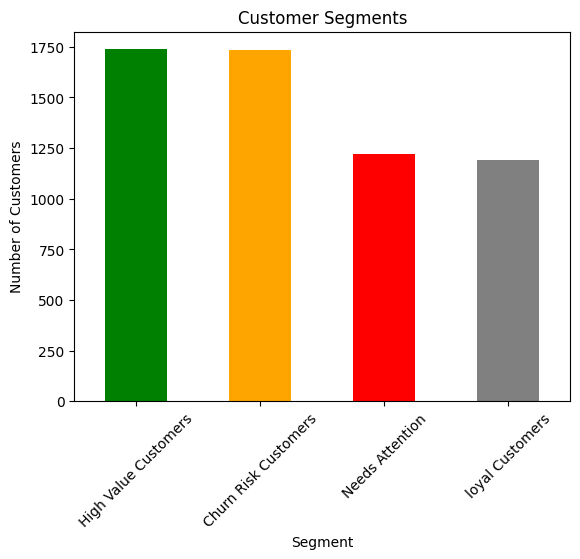

In [ ]:
# rfm['Segment'].value_counts().plot(kind='bar',color=['green','orange','red','grey'])
# plt.title('Customer Segments')
# plt.ylabel('Number of Customers')
# plt.xticks(rotation=45)
# plt.show()

Business spending money acquiring new customers at the same rate you're losing existing ones. You're running on a treadmill. Fix retention first it's cheaper and your cohort data shows exactly where to intervene: the first 30 days.

##**RFM Analysis Insights**

- **50/50 split is alarming:** Nearly equal numbers of loyal/high-value
  customers vs at-risk/lost customers. A healthy business should skew
  heavily toward loyal.

- **Loyal customers are likely older cohorts:** The "loyal" segment is
  probably carried by 2009-2010 customers. Newer cohorts haven't proven
  themselves yet and historical trends suggest they won't.

- **The bucket is leaking at the same rate it fills:** New customers
  coming in = existing customers churning out. The business is creating
  no net value — just running in place.

- **Fix retention before acquisition:** Retaining a customer is 5-7x
  cheaper than acquiring one. The first 30 days post-purchase is the
  critical intervention window based on cohort findings.

- **Data limitation:** 2011 cohorts are incomplete — we cannot fully
  judge newer customers yet. But the trend is not promising.

In [ ]:
rfm.columns

Index(['Recency', 'Frequency', 'Monetary', 'R Score', 'F Score', 'M Score',
       'RFM_Segment', 'RFM_Score', 'Segment'],
      dtype='object')

In [ ]:
# rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(0)

,Recency,Frequency,Monetary
Segment,,,
Churn Risk Customers,415.0,1.0,298.0
High Value Customers,37.0,15.0,8244.0
Needs Attention,212.0,3.0,803.0
loyal Customers,115.0,4.0,1612.0


**RFM Business Recommendations**

- **Churn Risk (101 days, 1 purchase, £293 avg):** Win-back email campaign
  with time-limited discount. They tried once — give them a reason to return.

- **Needs Attention (288 days, 2 purchases, £659 avg):** Re-engagement
  campaign with personalized recommendations based on past purchases.

- **Loyal (156 days, 11 purchases, £5554 avg):** Launch loyalty program
  NOW before they slide into Needs Attention. Reward them before they leave.

- **High Value (185 days, 11 purchases, £5231 avg):** VIP treatment —
  exclusive access, personal outreach. Losing one High Value customer =
  losing £5231. Protect them first.




**That's a 17x difference. Losing one High Value customer = gaining 17 Churn Risk customers just to break even**

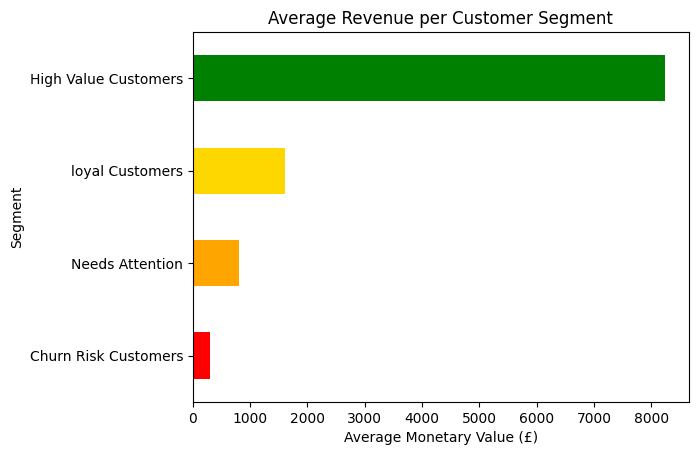

In [ ]:
# segment_summary = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(0)

# segment_summary['Monetary'].sort_values().plot(kind='barh', color=['red','orange','gold','green'])
# plt.title('Average Revenue per Customer Segment')
# plt.xlabel('Average Monetary Value (£)')
# plt.show()

**Churn Risk-** Win-back email — "We miss you, here's 20% off your next order" — create urgency

**Needs Attention-** Re-engagement campaign "It's been a while, look what's new" + personalized recommendations based on past purchases

**Loyal** Loyalty program reward them BEFORE they leave, points system, early access to sales

**High Value** VIP treatment personal account manager, exclusive products, early previews — make them feel special

# **NEWER IMPROVED RMF APPROACH**

Improved approach which is cell based approach

Uses R and F independently to preserve behavioral information
 M used for priority ranking within segments, not segmentation itself

why because
Same M. Completely different customers.

Customer A bought one huge order and disappeared — maybe a one-time bulk buyer
Customer B buys regularly and was just here — loyal and active

If you used M in segmentation, both land in the same "High Value" bucket. But they need completely different treatment:

A needs a win-back campaign
B needs a loyalty reward

In [46]:
def rfm_segment(row):
    r = row['R Score']
    f = row['F Score']

    if r >= 3 and f >= 3:
        return 'High Value Customers'
    elif r >= 3 and f < 3:
        return 'Emerging Customers'
    elif r < 3 and f >= 3:
        return 'At-Risk Loyal Customers'
    elif r < 3 and f < 3:
        return 'Inactive Customers'

In [47]:
rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

In [48]:
rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(0)

,Recency,Frequency,Monetary
Segment,,,
At-Risk Loyal Customers,276.0,7.0,2572.0
Emerging Customers,40.0,2.0,860.0
High Value Customers,29.0,13.0,6613.0
Inactive Customers,411.0,1.0,533.0


**Customer Segment Explanation**

- **High Value Customers**  
  Customers who purchase recently and frequently.They are the most valuable and engaged customer group.

- **Emerging Customers**  
  Customers who purchased recently but buy less often.They have strong potential to become loyal customers.

- **At-Risk Loyal Customers**  
  Customers who used to purchase frequently but have become less active recently.They require retention and win-back strategies.

- **Inactive Customers**  
  Customers with low recent activity and low purchase frequency.They are likely to churn or already disengaged.

In [52]:
rfm['Segment'].value_counts()

,count
Segment,
High Value Customers,2059
Inactive Customers,2046
Emerging Customers,895
At-Risk Loyal Customers,881


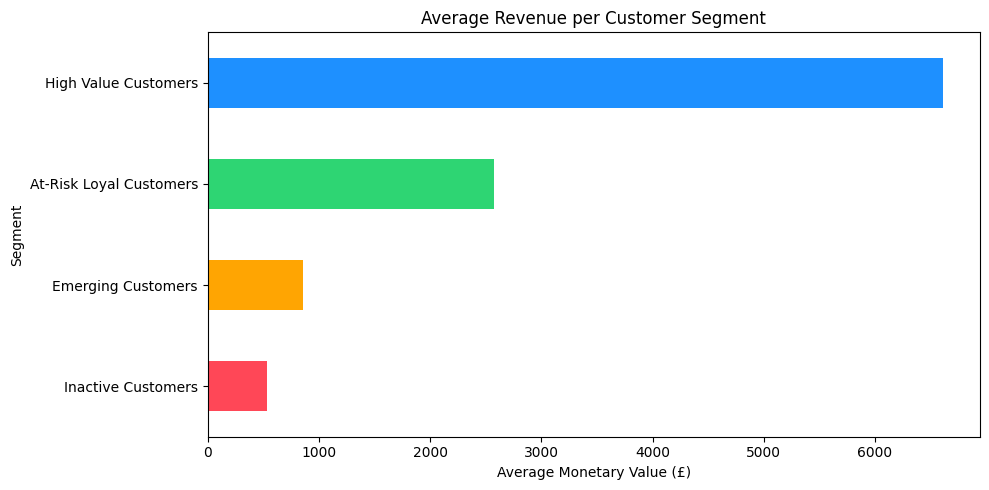

In [56]:
# RFM segment bar chart
segment_summary['Monetary'].sort_values().plot(
    kind='barh',
    color=['#ff4757','#ffa502','#2ed573','#1e90ff'],
    figsize=(10,5)
)
plt.title('Average Revenue per Customer Segment')
plt.xlabel('Average Monetary Value (£)')
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

## The Business Case Where to Act and Why

**The retention math is unforgiving:**
Losing 1 High Value customer (£6,613) requires acquiring 12 Inactive
customers just to break even. Retention is not a strategy. It is survival.



### Priority 1 — Protect High Value Customers (2059 customers)
Highest frequency. Most recent. Highest spend.
These customers are the engine of this business right now.
VIP treatment, exclusive access, personal outreach  make them
feel irreplaceable before they quietly become At-Risk Loyals.

Revenue protected: 2059 × £6,613 = **£13,617,167**



### Priority 2 — Win Back At-Risk Loyals (881 customers)
These customers bought 7 times. They are not gone — they are waiting.
A targeted re-engagement campaign with personalised recommendations
based on purchase history is the single highest ROI action available.

Potential revenue at stake: 881 × £2,572 = **£2,265,932**

This segment alone outweighs the combined value of Emerging and
Inactive customers. One campaign. Highest return. Start here.



### Priority 3 — Convert Emerging Customers (895 customers)
Frequency of 2 means they came back once — which most customers never do.
That is a buying signal. Reward it immediately with exclusive discounts
or early access before this window closes.

Miss this moment and they become Inactive in 6 months.

Potential revenue at stake: 895 × £860 = **£769,700**



### The Total Revenue at Stake

| Priority | Segment | Customers | Avg Value | Revenue at Stake |
|---|---|---|---|---|
| 1st | High Value | 2059 | £6,613 | £13,617,167 |
| 2nd | At-Risk Loyal | 881 | £2,572 | £2,265,932 |
| 3rd | Emerging | 895 | £860 | £769,700 |
| **Total** | | | | **£16,652,799** |

If this business does nothing, **£16.6M in customer value is at risk.**
That is the cost of inaction. Every day without a retention strategy
is a day this number gets harder to recover.

# **CHURN MODEL**

Inter purchase interval = average number of days between a customer purchase
Example Customer A bought on JAN 1, JAN 15, FEB 26, MARCH 19

therefore the average gap is jan15 - jan 1 = 15 days, feb 26 -15= 42 days ,march 19 - feb 26 = 38 days so average is 31 days , so this customer normal buying cycle is every 31 days, if today may 15 they have not purchased anything which is more than normal buying cycle then they have churned

churn is done customer level data not product per invoice like a orginal a df

In [57]:
inter_purchase = df.groupby('Customer ID')['InvoiceDate'].apply(
    lambda x: x.sort_values().diff().dt.days.mean()
).reset_index()

inter_purchase.columns = ['Customer ID' , 'AvgDaysBetweenPurchases']

In [58]:
inter_purchase.head(10)

,Customer ID,AvgDaysBetweenPurchases
0,12346.0,11.969697
1,12347.0,1.583333
2,12348.0,7.240000
3,12349.0,3.270115
4,12350.0,0.000000
5,12351.0,0.000000
6,12352.0,3.460784
7,12353.0,8.869565
8,12354.0,0.000000
9,12355.0,10.382353


In [59]:
inter_purchase['AvgDaysBetweenPurchases'].describe()

,AvgDaysBetweenPurchases
count,5767.000000
mean,5.145994
std,17.357533
min,0.000000
25%,0.000000
50%,1.856410
75%,4.787790
max,596.000000


In [60]:
inter_purchase['AvgDaysBetweenPurchases'] = inter_purchase['AvgDaysBetweenPurchases'].round()

In [61]:
(inter_purchase['AvgDaysBetweenPurchases'] == 0).sum()

np.int64(1822)

So 1822 out of 5881 customers = 31% of customers only ever bought on one day.


In [62]:
inter_purchase.shape

(5881, 2)

In [63]:
median_gap = inter_purchase[inter_purchase['AvgDaysBetweenPurchases']>0]['AvgDaysBetweenPurchases'].median()
print(median_gap)

3.0


The customers who ARE active are very active reordering every 3 days. But the business is losing customers faster than it's replacing them. The problem isn't how often loyal customers buy it's that loyal customers are disappearing.we found biggest dropoff is Month 0→1 in cohort That validates why we're using 2x inter-purchase interval as threshold

In [64]:
inter_purchase['ChurnThreshold'] = inter_purchase['AvgDaysBetweenPurchases'].apply(
    lambda x: median_gap * 2 if x == 0 else x * 2
)

inter_purchase.head(10)

,Customer ID,AvgDaysBetweenPurchases,ChurnThreshold
0,12346.0,12.0,24.0
1,12347.0,2.0,4.0
2,12348.0,7.0,14.0
3,12349.0,3.0,6.0
4,12350.0,0.0,6.0
5,12351.0,0.0,6.0
6,12352.0,3.0,6.0
7,12353.0,9.0,18.0
8,12354.0,0.0,6.0
9,12355.0,10.0,20.0


This code creates a customer specific churn threshold based on purchasing behavior. If a customer has a avg days more than 0 then days is multipled with 2 for this customer threshold; otherwise, customers with a 0-day gap use twice the overall median purchase gap as a fallback. which is 6 days here since median gap is 3

In [65]:
#merge inter_purchase with rfm
rfm = rfm.merge(inter_purchase, on ='Customer ID', how='left')

rfm['Churned'] = (rfm['Recency'] > rfm['ChurnThreshold']).astype(int) # marking churn

#checking the values
rfm['Churned'].value_counts()

,count
Churned,
1,5096
0,785


In [66]:
rfm['AvgDaysBetweenPurchases'] = rfm['AvgDaysBetweenPurchases'].fillna(median_gap)

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

#Feature and target
features = ['Recency','Frequency','Monetary']
X = rfm[features]
y = rfm['Churned']


#train test split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [68]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [69]:
#model comparison
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced',random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced',random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced',random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}


In [70]:
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='f1')
    results[name] = {
        'Mean F1': scores.mean().round(3),
        'Std': scores.std().round(3)
    }

results_df = pd.DataFrame(results).T
print(results_df)

                     Mean F1    Std
Logistic Regression    0.680  0.007
Decision Tree          0.938  0.005
Random Forest          0.957  0.003
Gradient Boosting      0.959  0.002


In [71]:
from sklearn.ensemble import GradientBoostingClassifier

final_model = GradientBoostingClassifier(random_state=42)
final_model.fit(X_scaled, y)

rfm['ChurnProbability'] = final_model.predict_proba(X_scaled)[:, 1]
rfm['ChurnRisk'] = pd.cut(rfm['ChurnProbability'],
                           bins=[0, 0.3, 0.7, 1.0],
                           labels=['Low Risk', 'Medium Risk', 'High Risk'])

In [72]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R Score,F Score,M Score,RFM_Segment,Segment,AvgDaysBetweenPurchases,ChurnThreshold,Churned,ChurnProbability,ChurnRisk
0,12346.0,325,12,77556.46,2,4,4,244,At-Risk Loyal Customers,12.0,24.0,1,0.990098,High Risk
1,12347.0,1,8,5633.32,4,4,4,444,High Value Customers,2.0,4.0,0,0.011218,Low Risk
2,12348.0,74,5,2019.40,3,3,3,333,High Value Customers,7.0,14.0,1,0.980863,High Risk
3,12349.0,18,4,4428.69,4,3,4,434,High Value Customers,3.0,6.0,1,0.901162,High Risk
4,12350.0,309,1,334.40,2,1,1,211,Inactive Customers,0.0,6.0,1,0.969084,High Risk


In [73]:
final_output = rfm[['Customer ID', 'Segment', 'Recency', 'Frequency',
                      'Monetary', 'ChurnProbability', 'ChurnRisk']].copy()

final_output = final_output.sort_values(
    by=['ChurnProbability', 'Monetary'],
    ascending=[False, False]
)

final_output.head(20)

,Customer ID,Segment,Recency,Frequency,Monetary,ChurnProbability,ChurnRisk
135,12482.0,At-Risk Loyal Customers,575,29,23691.40,0.997946,High Risk
5445,17850.0,At-Risk Loyal Customers,371,155,56600.08,0.997626,High Risk
743,13093.0,At-Risk Loyal Customers,275,55,54943.65,0.997450,High Risk
4367,16754.0,At-Risk Loyal Customers,371,29,67502.47,0.997352,High Risk
5051,17448.0,At-Risk Loyal Customers,496,46,14556.97,0.997219,High Risk
487,12835.0,At-Risk Loyal Customers,427,41,6043.31,0.996925,High Risk
3432,15808.0,At-Risk Loyal Customers,305,21,18409.93,0.996469,High Risk
1769,14134.0,At-Risk Loyal Customers,382,15,11123.35,0.996096,High Risk
4836,17230.0,At-Risk Loyal Customers,263,18,9924.95,0.996096,High Risk
1353,13715.0,At-Risk Loyal Customers,280,17,8483.29,0.996096,High Risk


In [74]:
print(rfm['ChurnRisk'].value_counts())
print("\n")
print(rfm.groupby('ChurnRisk')['Monetary'].mean().round(0))

ChurnRisk
High Risk      5115
Low Risk        434
Medium Risk     332
Name: count, dtype: int64


ChurnRisk
Low Risk       10581.0
Medium Risk     3989.0
High Risk       2312.0
Name: Monetary, dtype: float64


/tmp/ipykernel_11454/2392364213.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(rfm.groupby('ChurnRisk')['Monetary'].mean().round(0))


Your most valuable customers are NOT your highest churn risk. Your low-risk customers are worth 4.5x more on average.

So the real priority list is:

Protect Low Risk + High Monetary → don't let them slide
Win back Medium Risk + High Monetary → still recoverable
Selective win-back of High Risk → only the high monetary ones worth the effort

In [75]:
priority_table = rfm.groupby(['Segment', 'ChurnRisk']).agg(
    Customers=('Customer ID', 'count'),
    Avg_Monetary=('Monetary', 'mean'),
    Avg_Recency=('Recency', 'mean')
).round(0)

priority_table = priority_table.sort_values('Avg_Monetary', ascending=False)
print(priority_table)

                                     Customers  Avg_Monetary  Avg_Recency
Segment                 ChurnRisk                                        
High Value Customers    Low Risk           330       13254.0          2.0
                        Medium Risk        196        6514.0          9.0
                        High Risk         1533        5196.0         37.0
At-Risk Loyal Customers High Risk          881        2572.0        276.0
Emerging Customers      Low Risk            87        2508.0          3.0
                        High Risk          730         696.0         47.0
                        Medium Risk         78         561.0         16.0
Inactive Customers      High Risk         1971         551.0        410.0
                        Medium Risk         58          66.0        428.0
                        Low Risk            17          14.0        513.0
At-Risk Loyal Customers Low Risk             0           NaN          NaN
                        Medium Risk   

/tmp/ipykernel_11454/40338107.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  priority_table = rfm.groupby(['Segment', 'ChurnRisk']).agg(


**Churn Prediction — Priority Actions**

**The Burning Platform**
Total revenue at stake across all High Risk customers: **£7.96M**
Even a 10% recovery rate = **£796,000** ,3.6x more than protecting
all Low Risk Emerging customers combined.


**Priority 1 — High Value, Low Risk (330 customers, £4.37M)**
Recency of just 2 days — closest to median buying cycle.
These customers are still active and reachable.
**Action: VIP treatment immediately.** Exclusive access, personal
outreach, loyalty rewards. This is your most convertible revenue.

**Priority 2 — High Value, High Risk (1533 customers, £7.96M)**
Largest revenue pool in the entire customer base.
Already churning but worth aggressive win-back.
**Action: Targeted win-back campaign this week.**
10% recovery = £796,000 — survival money for this business.

**Priority 3 — High Value, Medium Risk (196 customers, £1.27M)**
Recency of 9 days — 3x their buying cycle but still recoverable.
More valuable than entire Inactive bucket combined.
**Action: Time-limited discounts to create urgency.**

**Priority 4 — At-Risk Loyal, High Risk (881 customers, £2.27M**)
276 days silent — 92x their median gap.
Money is there but conversion probability is low.
**Action: Low-cost re-engagement only.** Personalized recommendations,
no heavy discounts. Don't overspend on low probability.

**Do Not Prioritize**
Inactive customers — 400+ days silent, £551 avg.
Cost of win-back campaigns exceeds expected revenue recovery.

# **FINAL BUSINESS RECOMMENDATION**

In [76]:
final_output = rfm[['Customer ID', 'Segment', 'ChurnRisk',
                     'Recency', 'Frequency', 'Monetary',
                     'ChurnProbability']].copy()

# Define business priority order
segment_priority = {
    'High Value Customers': 1,
    'At-Risk Loyal Customers': 2,
    'Emerging Customers': 3,
    'Inactive Customers': 4
}

risk_priority = {
    'Low Risk': 1,
    'High Risk': 2,
    'Medium Risk': 3
}

final_output['SegmentPriority'] = final_output['Segment'].map(segment_priority)
final_output['RiskPriority'] = final_output['ChurnRisk'].map(risk_priority)

final_output = final_output.sort_values(
    by=['SegmentPriority', 'RiskPriority', 'Monetary'],
    ascending=[True, True, False]
)
action_map = {
    ('High Value Customers', 'Low Risk'): ' VIP Call — Loyalty Reward',
    ('High Value Customers', 'High Risk'): ' Urgent Win-Back Email',
    ('High Value Customers', 'Medium Risk'): ' Send Time-Limited Offer',
    ('At-Risk Loyal Customers', 'High Risk'): 'Personalised Recommendation',
    ('Emerging Customers', 'Low Risk'): 'Nurture — Early Access Deal',
    ('Emerging Customers', 'Medium Risk'): 'Send Discount Code',
    ('Emerging Customers', 'High Risk'): 'Low-Cost Re-engagement',
    ('Inactive Customers', 'High Risk'): ' Do Not Prioritise',
    ('Inactive Customers', 'Medium Risk'): 'Do Not Prioritise',
    ('Inactive Customers', 'Low Risk'): 'Do Not Prioritise',
    ('At-Risk Loyal Customers', 'Low Risk'): 'Personalised Recommendation',
    ('At-Risk Loyal Customers', 'Medium Risk'): 'Personalised Recommendation',
}

final_output['Action'] = list(zip(final_output['Segment'], final_output['ChurnRisk']))
final_output['Action'] = final_output['Action'].map(action_map)

final_output['Monetary'] = final_output['Monetary'].round(0)
final_output['ChurnProbability'] = (final_output['ChurnProbability'] * 100).round(1).astype(str) + '%'

final_output = final_output.drop(columns=['SegmentPriority', 'RiskPriority'])

final_output.head(100)

,Customer ID,Segment,ChurnRisk,Recency,Frequency,Monetary,ChurnProbability,Action
5695,18102.0,High Value Customers,Low Risk,0,145,608822.0,1.1%,VIP Call — Loyalty Reward
2279,14646.0,High Value Customers,Low Risk,1,152,528603.0,1.1%,VIP Call — Loyalty Reward
2541,14911.0,High Value Customers,Low Risk,0,398,295973.0,1.1%,VIP Call — Loyalty Reward
5112,17511.0,High Value Customers,Low Risk,2,60,175604.0,1.2%,VIP Call — Loyalty Reward
5543,17949.0,High Value Customers,Low Risk,0,118,118628.0,1.1%,VIP Call — Loyalty Reward
...,...,...,...,...,...,...,...,...
1174,13534.0,High Value Customers,Low Risk,1,35,7721.0,1.1%,VIP Call — Loyalty Reward
1347,13709.0,High Value Customers,Low Risk,3,18,7592.0,21.2%,VIP Call — Loyalty Reward
5202,17602.0,High Value Customers,Low Risk,1,14,7451.0,1.1%,VIP Call — Loyalty Reward
1749,14113.0,High Value Customers,Low Risk,3,16,7093.0,21.2%,VIP Call — Loyalty Reward


In [77]:
final_output.to_csv('customer_action_list.csv', index=False)
print(f"Exported {len(final_output)} customers")
print(final_output.head(10))

Exported 5881 customers
      Customer ID               Segment ChurnRisk  Recency  Frequency  \
5695      18102.0  High Value Customers  Low Risk        0        145   
2279      14646.0  High Value Customers  Low Risk        1        152   
2541      14911.0  High Value Customers  Low Risk        0        398   
5112      17511.0  High Value Customers  Low Risk        2         60   
5543      17949.0  High Value Customers  Low Risk        0        118   
2938      15311.0  High Value Customers  Low Risk        0        208   
739       13089.0  High Value Customers  Low Risk        2        203   
1435      13798.0  High Value Customers  Low Risk        0        110   
5436      17841.0  High Value Customers  Low Risk        1        211   
1732      14096.0  High Value Customers  Low Risk        3         17   

      Monetary ChurnProbability                      Action  
5695  608822.0             1.1%   VIP Call — Loyalty Reward  
2279  528603.0             1.1%   VIP Call — Loy

In [78]:
final_output.groupby(['Segment', 'ChurnRisk']).size().reset_index()

/tmp/ipykernel_11454/615367367.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final_output.groupby(['Segment', 'ChurnRisk']).size().reset_index()


,Segment,ChurnRisk,0
0,At-Risk Loyal Customers,Low Risk,0
1,At-Risk Loyal Customers,Medium Risk,0
2,At-Risk Loyal Customers,High Risk,881
3,Emerging Customers,Low Risk,87
4,Emerging Customers,Medium Risk,78
5,Emerging Customers,High Risk,730
6,High Value Customers,Low Risk,330
7,High Value Customers,Medium Risk,196
8,High Value Customers,High Risk,1533
9,Inactive Customers,Low Risk,17


In [79]:
final_output[['Segment', 'ChurnRisk']].drop_duplicates().head(20)

,Segment,ChurnRisk
5695,High Value Customers,Low Risk
1332,High Value Customers,Medium Risk
1791,High Value Customers,High Risk
0,At-Risk Loyal Customers,High Risk
4064,Emerging Customers,Low Risk
1505,Emerging Customers,Medium Risk
11,Emerging Customers,High Risk
119,Inactive Customers,Low Risk
3426,Inactive Customers,Medium Risk
2725,Inactive Customers,High Risk


In [80]:
high_priority = final_output[
    final_output['Segment'] == 'High Value Customers'
].copy()
high_priority.to_csv('high_priority_customers.csv', index=False)
print(f"High Priority Customers: {len(high_priority)}")

High Priority Customers: 2059
